# Tutorial 3: Model Grids and Performance

This tutorial explores pre-computed model grids for fast SED generation and performance optimization.

## Topics Covered

1. **GridGenerator** for creating custom grids
2. **StarGrid** for fast SED lookups
3. **Performance comparison**: StarGrid vs StarEvolTrack
4. **Loading and inspecting existing grids**
5. **Understanding reddening coefficients** in grids
6. **Reddened SED generation** with `get_seds`

## Prerequisites

This tutorial requires the following brutus data files:
- `MIST_1.2_EEPtrk.h5` - MIST evolutionary tracks
- `nn_c3k.h5` - Neural network for bolometric corrections
- `grid_mist_v9.h5` (optional) - Pre-computed MIST grid
- `grid_bayestar_v5.h5` (optional) - Pre-computed Bayestar grid

If you don't have these files, run the optional download cell below.

In [1]:
# Optional: Download required data files (only needed if not already cached)
# This tutorial requires MIST evolutionary tracks, the C3K neural network,
# and optionally pre-computed model grids.
# Uncomment the lines below to download them.

# from brutus.data import fetch_tracks, fetch_nns, fetch_grids
# fetch_tracks()                  # ~60 MB  -- MIST evolutionary tracks
# fetch_nns()                     # ~50 MB  -- Neural network for bolometric corrections
# fetch_grids()                   # ~600 MB -- Pre-computed MIST grid (grid_mist_v9)
# fetch_grids('bayestar_v5')      # ~80 MB  -- Pre-computed Bayestar grid (grid_bayestar_v5)

In [2]:
# Imports and setup
import time
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from tutorial_utils import (
    setup_tutorial,
    find_brutus_data_file,
    save_figure as _save_fig,
    print_section,
)

info = setup_tutorial(3, title="Tutorial 03: Model Grids and Performance")
plots_dir = info['plot_dir']


def save_figure(fig, name):
    """Save figure to this tutorial's plot directory."""
    _save_fig(fig, 3, name)


Tutorial 03: Model Grids and Performance

Checking data requirements for Tutorial 3
  Found: nn_c3k.h5
  Found: MIST_1.2_EEPtrk.h5
  Found: grid_mist_v9.h5
  Missing: grid_bayestar_v5.h5

  Missing 1 required file(s)


## Section 1: Creating Model Grids with GridGenerator

GridGenerator creates pre-computed model grids with reddening coefficients.
This enables fast SED generation for large-scale fitting applications.

### Key Concepts

- **Grid parameters**: Define the parameter space to sample (mass, metallicity, EEP, etc.)
- **Reddening coefficients**: Store polynomial coefficients for fast extinction calculations
- **Reference distance**: All grids use 1 kpc (1000 pc) reference distance
- **Storage format**: HDF5 files with labels, parameters, and magnitude coefficients

In [3]:
from brutus.core import EEPTracks, GridGenerator
from brutus.data import filters

# Initialize components
print("Loading MIST tracks and neural networks...")
mistfile = find_brutus_data_file('MIST_1.2_EEPtrk.h5')
nnfile = find_brutus_data_file('nn_c3k.h5')

# Use subset of filters for speed
filt = filters.ps[:3] + filters.tmass[:2]  # g,r,i + J,H
print(f"Using filters: {', '.join(filt)}")

tracks = EEPTracks(mistfile=mistfile, verbose=False)
print("Loaded EEPTracks")

Loading MIST tracks and neural networks...
Using filters: PS_g, PS_r, PS_i, 2MASS_J, 2MASS_H
Loaded EEPTracks


In [4]:
# Create grid generator
print("Initializing GridGenerator...")
generator = GridGenerator(
    tracks=tracks,
    nnfile=nnfile,
    filters=filt,
    verbose=True
)

print("\nDefining grid parameters for a small demo grid...")

# Define small grid for demonstration
mini_grid = np.array([0.5, 0.8, 1.0, 1.5, 2.0])  # 5 masses
feh_grid = np.array([-1.0, 0.0, 0.3])  # 3 metallicities
eep_grid = np.linspace(300, 500, 21)  # 21 EEP points (MS only)
afe_grid = np.array([0.0])  # Single alpha
smf_grid = np.array([0.0])  # No binaries for speed

total_models = len(mini_grid) * len(feh_grid) * len(eep_grid) * len(afe_grid) * len(smf_grid)
print(f"\nGrid dimensions:")
print(f"  Masses: {len(mini_grid)} points")
print(f"  Metallicities: {len(feh_grid)} points")
print(f"  EEPs: {len(eep_grid)} points")
print(f"  Total models to generate: {total_models}")

Initializing GridGenerator...

Defining grid parameters for a small demo grid...

Grid dimensions:
  Masses: 5 points
  Metallicities: 3 points
  EEPs: 21 points
  Total models to generate: 315


Grid filters: [np.str_('PS_g'), np.str_('PS_r'), np.str_('PS_i'), np.str_('2MASS_J'), np.str_('2MASS_H')]
Initializing FastNN predictor...done!


> **Note:** The sampling above is deliberately very sparse (5 masses, 3 metallicities,
> 21 EEP points) and is intended **for illustration only**. A grid this coarse is not
> suitable for science applications. For production-quality grid sampling strategies and
> parameter spacing, see Speagle et al. (2025).

In [5]:
# Generate the grid
print("\nGenerating model grid (this may take a minute)...")
start_time = time.time()

generator.make_grid(
    mini_grid=mini_grid,
    feh_grid=feh_grid,
    eep_grid=eep_grid,
    afe_grid=afe_grid,
    smf_grid=smf_grid,
    av_grid=np.linspace(0, 3, 4),  # For reddening coefficients
    rv_grid=np.array([3.32]),
    verbose=False
)

gen_time = time.time() - start_time
print(f"\nGrid generation complete in {gen_time:.1f} seconds")
print(f"  Models generated: {len(generator.grid_labels)}")
print(f"  Valid models: {generator.grid_sel.sum()}")
print(f"  Time per model: {gen_time/generator.grid_sel.sum()*1000:.1f} ms")


Generating model grid (this may take a minute)...



Grid generation complete in 0.3 seconds
  Models generated: 315
  Valid models: 235
  Time per model: 1.3 ms


In [6]:
# Save the demo grid
demo_grid_file = plots_dir / 'demo_grid.h5'
print(f"\nSaving demo grid to {demo_grid_file}")

with h5py.File(demo_grid_file, 'w') as f:
    # Save valid models only
    valid = generator.grid_sel
    f.create_dataset('labels', data=generator.grid_labels[valid])
    f.create_dataset('parameters', data=generator.grid_params[valid])
    f.create_dataset('mag_coeffs', data=generator.grid_seds[valid])
    
    # Add metadata
    f.attrs['filters'] = str(filt)
    f.attrs['reference_distance_pc'] = 1000.0
    f.attrs['rv'] = 3.32
    f.attrs['generation_time'] = gen_time
    f.attrs['n_models'] = valid.sum()

print(f"Saved {valid.sum()} models to HDF5 file")
print(f"  File size: {demo_grid_file.stat().st_size / 1024**2:.2f} MB")


Saving demo grid to /home/user/brutus/tutorials/plots/tutorial_03/demo_grid.h5
Saved 235 models to HDF5 file
  File size: 0.04 MB


## Section 2: StarGrid for Fast SED Lookups

StarGrid wraps a pre-computed grid of magnitude coefficients for interactive
queries.  Given stellar parameters (mass, EEP, metallicity), it interpolates
the grid to return an SED at any extinction and distance.

### Role in the brutus pipeline

- **Interactive exploration**: `StarGrid.get_seds()` lets you query
  individual models by physical parameters via multi-linear interpolation.
- **BruteForce fitting**: The fitting engine accesses the raw `mag_coeffs`
  array directly, evaluating *every* grid model against each observed star
  in a single Numba-compiled pass — no per-model neural network call needed.
- **Compact storage**: Each model stores only 3 numbers per band
  (`mag`, `R`, `dR/dRv`), so reddening at any `(A_V, R_V)` is a
  simple linear operation.

In [7]:
from brutus.core import StarGrid
from brutus.data import load_models

# Try to load a pre-computed grid
print("Loading pre-computed MIST grid...")

try:
    grid_file = find_brutus_data_file('grid_mist_v9.h5')
    filt_grid = filters.ps[:5] + filters.tmass  # PS + 2MASS
    
    models, labels, mask = load_models(grid_file, filters=filt_grid)
    print(f"Loaded {len(models):,} models")
    print(f"  Filters: {', '.join(filt_grid)}")
    
    # Initialize StarGrid (positional: models, models_labels)
    grid = StarGrid(models, labels, filters=filt_grid)
    print("StarGrid initialized")
    
    grid_available = True
    
except FileNotFoundError:
    print("Pre-computed grid not found")
    print("  Using demo grid from Section 1 instead...")
    
    # Load the demo grid we just created
    with h5py.File(demo_grid_file, 'r') as f:
        labels = f['labels'][:]
        models = f['mag_coeffs'][:]
    
    grid = StarGrid(models, labels, filters=filt)
    grid_available = False

Loading pre-computed MIST grid...


Reading entire dataset (49 filters) once...


Extracting 8 requested filters from memory: ['PS_g', 'PS_r', 'PS_i', 'PS_z', 'PS_y', '2MASS_J', '2MASS_H', '2MASS_Ks']


Dropping constant 'afe' label column (single-afe grid, afe=0)...


Loaded 613,530 models
  Filters: PS_g, PS_r, PS_i, PS_z, PS_y, 2MASS_J, 2MASS_H, 2MASS_Ks
Loaded StarGrid with 613,530 models, 8 filters, 8 labels
StarGrid initialized


In [8]:
# Test StarGrid performance
print("\nTesting StarGrid performance...")

# Generate 100 SEDs for timing
n_test = 100
start = time.time()

for _ in range(n_test):
    try:
        mag, params, _ = grid.get_seds(
            mini=1.0, feh=0.0, eep=400,
            av=0.5, rv=3.32, dist=1000.0
        )
    except:
        # May fail if parameters are out of grid range
        pass

grid_time = (time.time() - start) / n_test
print(f"  Average time per SED: {grid_time*1000:.2f} ms")

# Show example output
mag, params, _ = grid.get_seds(
    mini=1.0, feh=0.0, eep=400,
    av=0.0, rv=3.32, dist=1000.0
)

print(f"\nExample SED for 1 M_sun star at 1 kpc:")
for i, f in enumerate(grid.filters[:min(5, len(grid.filters))]):
    print(f"  {f}: {mag[i]:.2f} mag")

if isinstance(params, dict) and 'loga' in params:
    print(f"\nDerived parameters:")
    print(f"  Age: {10**(params['loga'])/1e9:.2f} Gyr")
    print(f"  log L/L_sun: {params.get('logl', 'N/A'):.2f}")
    print(f"  log Teff: {params.get('logt', 'N/A'):.2f}")


Testing StarGrid performance...


  Average time per SED: 30.80 ms

Example SED for 1 M_sun star at 1 kpc:
  PS_g: 14.62 mag
  PS_r: 14.28 mag
  PS_i: 14.19 mag
  PS_z: 14.18 mag
  PS_y: 14.18 mag

Derived parameters:
  Age: 6.75 Gyr
  log L/L_sun: 0.14
  log Teff: 3.77


## Section 3: Performance Comparison

The real performance advantage of pre-computed grids shows up in
batch evaluation.  During fitting, `BruteForce` applies reddening
to **all** grid models at once using the stored magnitude coefficients.
Each evaluation is a simple linear operation — 3 multiplies and 2 adds
per model per band, compiled with Numba — instead of an expensive
neural-network forward pass.

Below we compare:
1. **StarEvolTrack**: N individual on-the-fly SED evaluations (track interpolation + neural network per call)
2. **`get_seds` on pre-computed coefficients**: Applying reddening to N stored `mag_coeffs` in a single batch call

In [9]:
from brutus.core import StarEvolTrack, get_seds

# Setup
filt_test = filters.ps[:3] + filters.tmass[:2]
tracks = EEPTracks(mistfile=mistfile, verbose=False)
star_evol = StarEvolTrack(tracks=tracks, nnfile=nnfile, filters=filt_test, verbose=False)

# ------------------------------------------------------------------
# Compare: N individual StarEvolTrack calls  vs  one batch get_seds call
# This mirrors what BruteForce does — it never calls StarGrid.get_seds()
# for single-point lookups. Instead it passes the entire mag_coeffs array
# to _get_seds() in one Numba-compiled pass.
# ------------------------------------------------------------------
rng = np.random.default_rng(42)
test_minis = rng.uniform(0.5, 2.0, 2000)
test_fehs = rng.uniform(-1, 0.3, 2000)
test_eeps = rng.uniform(300, 500, 2000)

# Warm up Numba JIT (first call compiles the function)
if grid_available:
    _ = get_seds(models[:2], av=np.array([0.5, 1.0]), rv=np.array([3.32, 3.32]))

n_values = [10, 50, 100, 500, 1000]
evol_times = []
grid_times = []

print("Per-model cost: StarEvolTrack (NN) vs get_seds (pre-computed coefficients)\n")

for n in n_values:
    # Method 1: N individual StarEvolTrack.get_seds() calls
    #   Each call runs: track interpolation -> NN forward pass -> extinction
    start = time.time()
    for i in range(n):
        try:
            star_evol.get_seds(mini=test_minis[i], feh=test_fehs[i],
                               eep=test_eeps[i], dist=1000.0)
        except Exception:
            pass
    t_evol = time.time() - start
    evol_times.append(t_evol)

    # Method 2: Single get_seds() call on N pre-computed mag_coeffs
    #   Just applies: m = mag + Av * (R + Rv * dR/dRv) for all N models
    if grid_available:
        idx = rng.choice(len(models), n, replace=False)
        batch_coeffs = models[idx]  # (N, Nfilt, 3)
        av_arr = rng.uniform(0, 2, n)
        rv_arr = np.full(n, 3.32)

        start = time.time()
        _ = get_seds(batch_coeffs, av=av_arr, rv=rv_arr)
        t_grid = time.time() - start
        grid_times.append(t_grid)

        speedup = t_evol / t_grid if t_grid > 0 else float('inf')
        print(f"  N={n:5d}:  StarEvolTrack = {t_evol*1000:8.1f} ms,  "
              f"get_seds = {t_grid*1000:8.3f} ms  "
              f"(batch {speedup:.0f}x faster)")
    else:
        grid_times.append(None)
        print(f"  N={n:5d}:  StarEvolTrack = {t_evol*1000:8.1f} ms")

print("\nStarEvolTrack cost is dominated by the neural-network forward pass")
print("and Python-level track interpolation on each call.")
print("get_seds applies a simple linear formula to pre-computed coefficients,")
print("so the batch cost grows negligibly with N.")

Per-model cost: StarEvolTrack (NN) vs get_seds (pre-computed coefficients)

  N=   10:  StarEvolTrack =      5.5 ms,  get_seds =    0.232 ms  (batch 24x faster)
  N=   50:  StarEvolTrack =     21.4 ms,  get_seds =    2.624 ms  (batch 8x faster)
  N=  100:  StarEvolTrack =     43.3 ms,  get_seds =    0.251 ms  (batch 172x faster)


  N=  500:  StarEvolTrack =    214.9 ms,  get_seds =    0.291 ms  (batch 739x faster)


  N= 1000:  StarEvolTrack =    451.7 ms,  get_seds =    0.268 ms  (batch 1683x faster)

StarEvolTrack cost is dominated by the neural-network forward pass
and Python-level track interpolation on each call.
get_seds applies a simple linear formula to pre-computed coefficients,
so the batch cost grows negligibly with N.


  Saved: /home/user/brutus/tutorials/plots/tutorial_03/performance_comparison.png


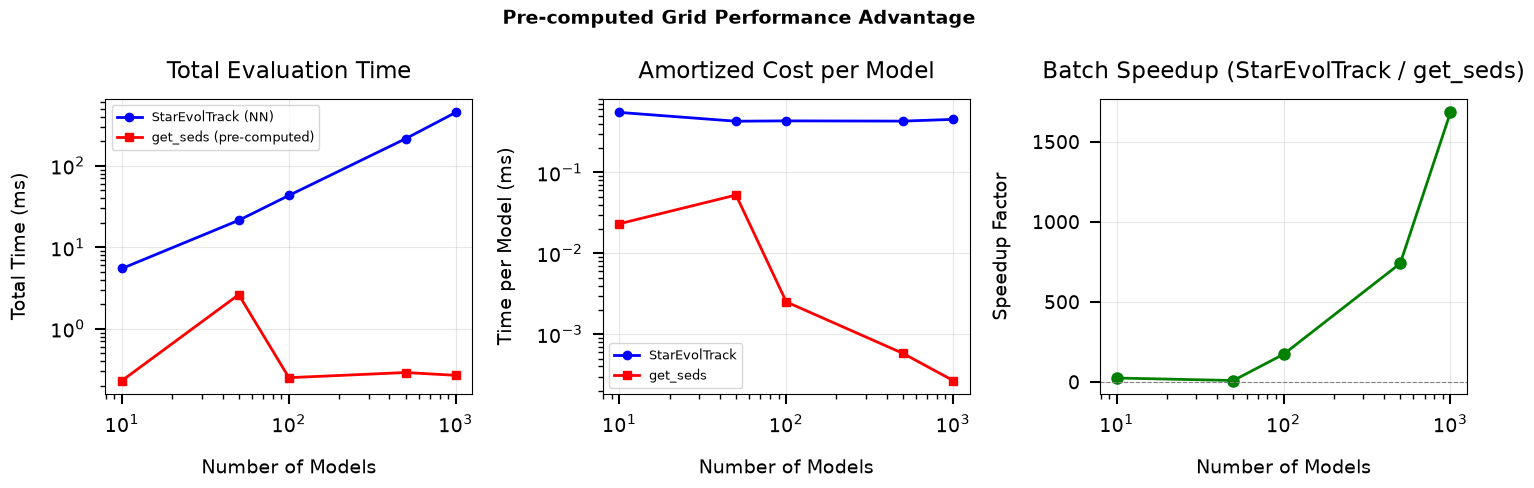


Pre-computed grids trade memory for speed: store mag_coeffs once,
then evaluate any (Av, Rv, dist) combination with trivial arithmetic.


In [10]:
# Performance comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

n_arr = np.array(n_values)
evol_arr = np.array(evol_times) * 1000  # ms

# Panel 1: Total time vs number of models
ax = axes[0]
ax.loglog(n_arr, evol_arr, 'bo-', lw=2, label='StarEvolTrack (NN)')

if grid_available and all(g is not None for g in grid_times):
    grid_arr = np.array(grid_times) * 1000
    ax.loglog(n_arr, grid_arr, 'rs-', lw=2, label='get_seds (pre-computed)')

ax.set_xlabel('Number of Models')
ax.set_ylabel('Total Time (ms)')
ax.set_title('Total Evaluation Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: Time per model (amortized)
ax = axes[1]
ax.loglog(n_arr, evol_arr / n_arr, 'bo-', lw=2, label='StarEvolTrack')

if grid_available and all(g is not None for g in grid_times):
    ax.loglog(n_arr, grid_arr / n_arr, 'rs-', lw=2, label='get_seds')

ax.set_xlabel('Number of Models')
ax.set_ylabel('Time per Model (ms)')
ax.set_title('Amortized Cost per Model')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 3: Speedup factor
ax = axes[2]
if grid_available and all(g is not None for g in grid_times):
    speedups = evol_arr / grid_arr
    ax.semilogx(n_arr, speedups, 'go-', lw=2, markersize=8)
    ax.set_xlabel('Number of Models')
    ax.set_ylabel('Speedup Factor')
    ax.set_title('Batch Speedup (StarEvolTrack / get_seds)')
    ax.grid(True, alpha=0.3)
    ax.axhline(1, color='gray', ls='--', lw=0.8)
else:
    ax.text(0.5, 0.5, 'Pre-computed grid\nnot available',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title('Batch Speedup')

plt.suptitle('Pre-computed Grid Performance Advantage', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'performance_comparison')
plt.show()

print("\nPre-computed grids trade memory for speed: store mag_coeffs once,")
print("then evaluate any (Av, Rv, dist) combination with trivial arithmetic.")

## Section 4: Working with Existing Grids

Brutus provides pre-computed grids for common use cases.
Let's explore the available grids and their properties.

### Available Grids

- **grid_mist_v9.h5**: Full MIST stellar evolution models
- **grid_bayestar_v5.h5**: Empirical Pan-STARRS models for dust mapping

> **Note:** These pre-computed grids have much denser sampling than the demo
> grid created above. For example, the MIST grid uses fine spacing in mass
> (typically ~0.01 M\u2609), EEP (~1\u20135), and metallicity (~0.05 dex).
> Inspect the grid metadata (shown below) for exact parameter ranges and
> spacing.

In [11]:
# Check for available grids
grids_to_check = [
    ('grid_mist_v9.h5', 'MIST v9', 'Full MIST stellar evolution models'),
    ('grid_bayestar_v5.h5', 'Bayestar v5', 'Empirical Pan-STARRS models'),
]

loaded_grids = []

for (filename, name, description) in grids_to_check:
    print(f"\n{name}: {description}")
    print("-" * 50)
    
    try:
        filepath = Path(find_brutus_data_file(filename))
        
        # Open to inspect
        with h5py.File(filepath, 'r') as f:
            print(f"  File: {filename}")
            print(f"  Size: {filepath.stat().st_size / 1024**2:.1f} MB")
            print(f"  Keys: {list(f.keys())}")
            
            if 'labels' in f:
                grid_labels = f['labels'][:]
                print(f"  Number of models: {len(grid_labels):,}")
                print(f"  Label fields: {grid_labels.dtype.names}")
                
                # Get parameter ranges
                if 'mini' in grid_labels.dtype.names:
                    print(f"  Mass range: {grid_labels['mini'].min():.2f} - {grid_labels['mini'].max():.2f} M\u2609")
                if 'feh' in grid_labels.dtype.names:
                    print(f"  [Fe/H] range: {grid_labels['feh'].min():.2f} - {grid_labels['feh'].max():.2f}")
                if 'Mr' in grid_labels.dtype.names:
                    print(f"  M_r range: {grid_labels['Mr'].min():.1f} - {grid_labels['Mr'].max():.1f}")
                
            if 'mag_coeffs' in f:
                mags = f['mag_coeffs']
                # mag_coeffs can be a structured array (filter names as fields,
                # each with 3 coefficients) or a regular (N, Nfilt, 3) array.
                if mags.dtype.names:
                    n_filters = len(mags.dtype.names)
                    print(f"  Magnitude coefficients: {len(mags):,} models x {n_filters} filters x 3 coefficients")
                    print(f"  Filter names: {', '.join(mags.dtype.names[:5])}...")
                else:
                    print(f"  Magnitude array shape: {mags.shape}")
            
            # Check metadata
            if f.attrs:
                print("  Metadata:")
                for key in list(f.attrs.keys())[:5]:
                    print(f"    {key}: {f.attrs[key]}")
            
            loaded_grids.append((name, grid_labels, filename))
            
    except FileNotFoundError:
        print(f"  [Not found - optional file]")


MIST v9: Full MIST stellar evolution models
--------------------------------------------------
  File: grid_mist_v9.h5
  Size: 744.3 MB
  Keys: ['labels', 'mag_coeffs', 'parameters']
  Number of models: 613,530
  Label fields: ('mini', 'eep', 'feh', 'afe', 'smf')
  Mass range: 0.50 - 2.00 M☉
  [Fe/H] range: -3.00 - 0.45
  Magnitude coefficients: 613,530 models x 49 filters x 3 coefficients
  Filter names: Gaia_G_MAW, Gaia_BP_MAWf, Gaia_RP_MAW, SDSS_u, SDSS_g...

Bayestar v5: Empirical Pan-STARRS models
--------------------------------------------------
  [Not found - optional file]


## Section 5: Understanding Reddening Coefficients

Model grids store reddening coefficients to enable fast extinction calculations
without needing to re-evaluate the neural network for each value of $A_V$.

### Reddening Parameterization

For each model and filter, the `mag_coeffs` array stores 3 values:
- **`mag`**: The unreddened apparent magnitude at the reference distance (1 kpc)
- **`R`**: The reddening vector component at $R_V = 0$
- **`dR/dR_V`**: The change in the reddening vector per unit $R_V$

The reddened magnitude in each band is then:

$$m_\lambda = \text{mag} + A_V \times (R + R_V \times dR/dR_V)$$

This parameterization captures the full wavelength-dependent extinction law
with only 3 stored numbers per model per band, enabling fast evaluation for
any combination of $A_V$ and $R_V$.

In [12]:
# Demonstrate the reddening coefficient structure
print("Reddening Coefficient Structure in brutus Grids\n")

print("Each model and filter stores 3 coefficients: [mag, R, dR/dRv]")
print()
print("  mag   : unreddened magnitude at 1 kpc reference distance")
print("  R     : reddening vector component at Rv=0")
print("  dR/dRv: change in reddening vector per unit Rv")
print()
print("Reddened magnitude:")
print("  m_lambda = mag + Av * (R + Rv * dR/dRv)")
print()
print("Benefits of this parameterization:")
print("  - Fast evaluation for any (Av, Rv) combination")
print("  - No neural network re-evaluation needed")
print("  - Linear in Av, linear in Rv")
print("  - Only 3 numbers per model per band")
print()

# Show example from the demo grid
# grid_seds is a structured array: each field is a filter name with shape (3,)
seds = generator.grid_seds
seds_fields = seds.dtype.names
print(f"Example from demo grid:")
print(f"  {len(seds)} models, {len(seds_fields)} filters, 3 coefficients each")

# Pick a valid model
valid_idx = np.where(generator.grid_sel)[0][0]
print(f"\nModel {valid_idx} coefficients:")
for fname in seds_fields:
    coeffs = seds[valid_idx][fname]
    print(f"  {fname}: mag={coeffs[0]:.2f}, R={coeffs[1]:.4f}, dR/dRv={coeffs[2]:.4f}")

Reddening Coefficient Structure in brutus Grids

Each model and filter stores 3 coefficients: [mag, R, dR/dRv]

  mag   : unreddened magnitude at 1 kpc reference distance
  R     : reddening vector component at Rv=0
  dR/dRv: change in reddening vector per unit Rv

Reddened magnitude:
  m_lambda = mag + Av * (R + Rv * dR/dRv)

Benefits of this parameterization:
  - Fast evaluation for any (Av, Rv) combination
  - No neural network re-evaluation needed
  - Linear in Av, linear in Rv
  - Only 3 numbers per model per band

Example from demo grid:
  315 models, 5 filters, 3 coefficients each

Model 0 coefficients:
  PS_g: mag=18.82, R=0.5640, dR/dRv=0.1699
  PS_r: mag=17.88, R=0.4111, dR/dRv=0.1238
  PS_i: mag=17.46, R=0.2871, dR/dRv=0.0865
  2MASS_J: mag=16.09, R=0.1091, dR/dRv=0.0329
  2MASS_H: mag=15.44, R=0.0672, dR/dRv=0.0202


## Section 6: Reddened SED Generation with `get_seds`

The `get_seds` function is the core utility for applying dust reddening to
pre-computed magnitude coefficients. Each model stores a compact representation
of how its photometry changes with extinction:

**`mag_coeffs` array** has shape `(Nmodels, Nbands, 3)` where the 3 coefficients are:
- **`mag`** (index 0): The unreddened apparent magnitude at the reference distance (1 kpc).
- **`R`** (index 1): The reddening vector component at `R(V) = 0`.
- **`dR/dRv`** (index 2): The change in the reddening vector per unit `R(V)`.

The reddened magnitude in each band is computed as:

$$m_\lambda = \text{mag} + A_V \times (R + R_V \times dR/dR_V)$$

This parameterization captures the full wavelength-dependent extinction law
with only 3 stored numbers per model per band, enabling extremely fast
evaluation for any combination of `A(V)` and `R(V)`.

In [13]:
# Demonstrate the get_seds function for applying reddening to mag_coeffs
try:
    from brutus.core import get_seds

    # --- Build synthetic mag_coeffs (Nmodels, Nbands, 3) ---
    # If a grid was loaded earlier we grab a few rows; otherwise we
    # construct a small illustrative array by hand.
    try:
        # Use the first 5 models from the loaded grid
        sample_coeffs = models[:5].copy()
        band_labels = filt_grid if grid_available else filt
        print("Using mag_coeffs from the loaded grid (first 5 models).")
    except Exception:
        # Create synthetic coefficients for 5 "models" and 5 "bands"
        Nmodels, Nbands = 5, 5
        band_labels = ['g', 'r', 'i', 'J', 'H']
        sample_coeffs = np.zeros((Nmodels, Nbands, 3))
        # Unreddened magnitudes (index 0) -- typical main-sequence values
        sample_coeffs[:, :, 0] = np.array([[18.0, 17.2, 16.8, 15.5, 15.0],
                                            [16.5, 15.8, 15.4, 14.3, 13.9],
                                            [15.0, 14.5, 14.2, 13.4, 13.1],
                                            [20.0, 19.0, 18.5, 17.0, 16.5],
                                            [22.0, 21.0, 20.5, 19.0, 18.5]])
        # R (reddening at Rv=0, index 1) -- roughly A_lambda / A_V at Rv=0
        sample_coeffs[:, :, 1] = np.array([1.20, 0.87, 0.68, 0.29, 0.18])
        # dR/dRv (index 2) -- change per unit Rv
        sample_coeffs[:, :, 2] = np.array([0.32, 0.24, 0.18, 0.08, 0.05])
        print("Created synthetic mag_coeffs for 5 models x 5 bands.")

    print(f"  mag_coeffs shape: {sample_coeffs.shape}")
    print(f"  Interpretation: (Nmodels={sample_coeffs.shape[0]}, "
          f"Nbands={sample_coeffs.shape[1]}, coeffs=[mag, R, dR/dRv])")

    # --- Call get_seds at different extinction levels ---
    seds_av0 = get_seds(sample_coeffs, av=0.0)
    seds_av1 = get_seds(sample_coeffs, av=1.0, rv=3.3)
    seds_av2 = get_seds(sample_coeffs, av=2.0, rv=3.3)

    print(f"\nUnreddened SEDs (A_V=0)  shape: {seds_av0.shape}")
    print(f"Reddened SEDs  (A_V=1)  shape: {seds_av1.shape}")
    print(f"Reddened SEDs  (A_V=2)  shape: {seds_av2.shape}")

    print(f"\nModel 0 magnitudes across bands:")
    header = "  {:>8s}".format("Band") + "    A_V=0    A_V=1    A_V=2"
    print(header)
    for j in range(min(sample_coeffs.shape[1], len(band_labels))):
        label = band_labels[j] if j < len(band_labels) else f"band_{j}"
        print(f"  {label:>8s}   {seds_av0[0, j]:7.3f}  {seds_av1[0, j]:7.3f}  "
              f"{seds_av2[0, j]:7.3f}")

    get_seds_available = True

except Exception as e:
    print(f"Could not run get_seds demo: {e}")
    get_seds_available = False

Using mag_coeffs from the loaded grid (first 5 models).
  mag_coeffs shape: (5, 8, 3)
  Interpretation: (Nmodels=5, Nbands=8, coeffs=[mag, R, dR/dRv])

Unreddened SEDs (A_V=0)  shape: (5, 8)
Reddened SEDs  (A_V=1)  shape: (5, 8)
Reddened SEDs  (A_V=2)  shape: (5, 8)

Model 0 magnitudes across bands:
      Band    A_V=0    A_V=1    A_V=2
      PS_g    18.197   19.344   20.491
      PS_r    17.573   18.407   19.242
      PS_i    17.286   17.865   18.443
      PS_z    17.150   17.591   18.032
      PS_y    17.074   17.433   17.791
   2MASS_J    16.142   16.371   16.600
   2MASS_H    15.678   15.818   15.957
  2MASS_Ks    15.567   15.653   15.739


## Summary and Key Takeaways

This tutorial has covered model grids and performance optimization in brutus:

### Key Classes

1. **GridGenerator**: Creates pre-computed model grids
   - Samples parameter space systematically
   - Computes reddening coefficients (`mag`, `R`, `dR/dRv` per band)
   - Saves to HDF5 format

2. **StarGrid**: Interactive SED queries via grid interpolation
   - Multi-linear interpolation for any point in parameter space
   - Supports all extinction and distance effects

3. **`get_seds`**: Batch reddening application
   - Applies `m = mag + Av * (R + Rv * dR/dRv)` to pre-computed coefficients
   - Orders of magnitude faster than per-model neural network evaluation
   - Used internally by `BruteForce` for fitting

### Performance Insights

- **Speed**: Pre-computed grids avoid per-model neural network calls during fitting
- **Reddening**: 3-coefficient parameterization enables fast evaluation at any `(Av, Rv)`
- **Scalability**: Grids enable fitting millions of stars with `BruteForce`

### Recommended Workflows

1. **Exploration**: Use `StarEvolTrack` for flexibility at individual points
2. **Production**: Generate custom grid for your parameter space with `GridGenerator`
3. **Large surveys**: Use pre-computed grids (MIST, Bayestar) with `BruteForce`

### Next Steps

- **Tutorial 4**: Galactic Priors and Population Synthesis
- **Tutorial 5**: Fitting Individual Sources with BruteForce
- **Tutorial 6**: Cluster Analysis and Population Fitting
- **Tutorial 7**: 3D Dust Mapping

In [14]:
print("Tutorial 3 Complete!")
print("="*60)
print("\nGenerated files and plots:")
for file in sorted(plots_dir.glob('*')):
    size = file.stat().st_size / 1024**2 if file.suffix == '.h5' else file.stat().st_size / 1024
    unit = 'MB' if file.suffix == '.h5' else 'KB'
    print(f"  - {file.name} ({size:.1f} {unit})")

Tutorial 3 Complete!

Generated files and plots:
  - demo_grid.h5 (0.0 MB)
  - existing_grids.png (184.2 KB)
  - get_seds_av_comparison.png (169.2 KB)
  - get_seds_reddening_vectors.png (192.1 KB)
  - grid_resolution.png (241.4 KB)
  - performance_comparison.png (127.7 KB)
  - reddening_coefficients.png (142.2 KB)
